In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, log_loss, average_precision_score
import shap
import joblib
from xgboost import XGBClassifier

## Helper Classes and Functions

In [2]:
class GenericCleaning:
    def __init__(self):
        pass
    def fit(self, X):
        print('Generic cleaning...')
        return self
    def transform(self, X):
        print('Generic cleaning...')
        X = X.copy()
        # replace terms w val 0
        X['term_months'] = X['term_months'].replace(0, np.nan)
        # clean channel
        X['channel'] = X['channel'].str.lower().str.strip()
        return X

In [3]:
class FillMissing:
    def __init__(self, dict_fillna):
        self.dict_fillna = dict_fillna
    def fit(self, X):
        print('Calculating imputation value...')
        dict_impute = {}
        for key, val in tqdm(self.dict_fillna.items()):
            if val == 'max':
                val_impute = X[key].max()
            elif val == 'min':
                val_impute = X[key].min()
            elif val == 'missing':
                val_impute = 'missing'
            # assign
            dict_impute[key] = val_impute
        # save to object
        self.dict_impute = dict_impute
        return self
    def transform(self, X):
        print('Filling missing values...')
        X = X.copy()
        dict_impute = self.dict_impute
        list_cols = list(X.columns)
        dict_impute = {key: val for key, val in dict_impute.items() if key in list_cols}
        # impute
        for key, val in tqdm(dict_impute.items()):
            X[key] = X[key].fillna(val)
        return X

In [4]:
class FeatureEngineering:
    def __init__(self):
        pass
    def fit(self, X):
        print('Feature engineering...')
        # get unique channels
        list_channels_unique = list(X['channel'].unique())
        # save to object
        self.list_channels_unique = list_channels_unique
        return self
    def transform(self, X):
        print('Feature engineering...')
        X = X.copy()
        # log income
        X['ENG-stated_income_log'] = np.log1p(X['stated_income'])
        # loan to income
        X['ENG-loan_to_income'] = X['loan_amount'] / (X['stated_income'] + 1)
        # one-hot encode channel
        for channel_unique in self.list_channels_unique:
            X[f'ENG-channel_{channel_unique}'] = (X['channel'] == channel_unique).astype(int)
        return X

In [5]:
class Winsorize:
    def __init__(self, list_cols_winsorize):
        self.list_cols_winsorize = list_cols_winsorize
    def fit(self, X):
        print('Calculating winsorization thresholds...')
        dict_bounds = {}
        for col in self.list_cols_winsorize:
            flt_lower = X[col].quantile(0.01)
            flt_upper = X[col].quantile(0.99)
            dict_bounds[col] = {'lower': flt_lower, 'upper': flt_upper}
        # save
        self.dict_bounds = dict_bounds
        return self
    def transform(self, X):
        print('Winsorizing features...')
        X = X.copy()
        dict_bounds = self.dict_bounds
        list_cols = list(X.columns)
        dict_bounds = {key: val for key, val in dict_bounds.items() if key in list_cols}
        for key, val in dict_bounds.items():
            X[key] = X[key].clip(val['lower'], val['upper'])
        return X

In [6]:
class PreprocessingModel:
    def __init__(self, list_cls_transformers):
        self.list_cls_transformers = list_cls_transformers
    def transform(self, X):
        for cls_transformer in self.list_cls_transformers:
            X = cls_transformer.transform(X)
        return X

In [7]:
def tune_model(X_train, y_train, X_valid, y_valid, X_test, y_test, dict_monotone_constraints):
    list_int_min_child_weight = [1, 5, 10]
    list_flt_gamma = [0, 0.5]
    list_int_max_depth = [3, 4, 5]
    flt_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
    
    int_total_iterations = len(list_int_min_child_weight) * len(list_flt_gamma) * len(list_int_max_depth)
    
    list_dict_row = []
    a = 1
    for int_min_child_weight in list_int_min_child_weight:
        for flt_gamma in list_flt_gamma:
            for int_max_depth in list_int_max_depth:
                # print
                print(f'Fitting model {a} / {int_total_iterations}')
                # initialize model
                cls_model_inference = XGBClassifier(
                    objective="binary:logistic",
                    eval_metric="logloss",
                    n_estimators=2000,
                    learning_rate=0.05,
                    max_depth=int_max_depth, # tuning
                    min_child_weight=int_min_child_weight, # tuning
                    gamma=flt_gamma, # tuning
                    subsample=0.8,
                    colsample_bytree=0.8,
                    reg_lambda=1.0,
                    scale_pos_weight=flt_pos_weight, # balancing class weights
                    monotone_constraints=dict_monotone_constraints,
                    random_state=42,
                    early_stopping_rounds=50,
                    tree_method="hist",
                )
                
                # fit model
                cls_model_inference.fit(
                    X_train,
                    y_train,
                    eval_set=[(X_valid, y_valid)],
                    verbose=False,
                )
                
                # predictions
                y_hat_train = cls_model_inference.predict_proba(X_train)[:, 1]
                y_hat_valid = cls_model_inference.predict_proba(X_valid)[:, 1]
                y_hat_test = cls_model_inference.predict_proba(X_test)[:, 1]
                
                # evaluate
                flt_roc_auc_train = roc_auc_score(y_train, y_hat_train)
                flt_roc_auc_valid = roc_auc_score(y_valid, y_hat_valid)
                flt_roc_auc_test = roc_auc_score(y_test, y_hat_test)
                
                flt_pr_auc_train = average_precision_score(y_train, y_hat_train)
                flt_pr_auc_valid = average_precision_score(y_valid, y_hat_valid)
                flt_pr_auc_test = average_precision_score(y_test, y_hat_test)
    
                # row
                dict_row = {
                    'flt_pos_weight': flt_pos_weight,
                    'int_min_child_weight': int_min_child_weight,
                    'flt_gamma': flt_gamma,
                    'int_max_depth': int_max_depth,
                    'flt_roc_auc_train': flt_roc_auc_train,
                    'flt_roc_auc_valid': flt_roc_auc_valid,
                    'flt_roc_auc_test': flt_roc_auc_test,
                    'flt_pr_auc_train': flt_pr_auc_train,
                    'flt_pr_auc_valid': flt_pr_auc_valid,
                    'flt_pr_auc_test': flt_pr_auc_test,
                    'int_best_iteration': cls_model_inference.get_booster().best_iteration,
                    'cls_model_inference': cls_model_inference,
                }
                list_dict_row.append(dict_row)
                a += 1
    # make df
    df_tuning = pd.DataFrame(list_dict_row)
    # sort by best validation metric
    df_tuning.sort_values(by='flt_pr_auc_valid', ascending=False, inplace=True)
    return df_tuning

## Constants

In [ ]:
str_bucket = 'credit-risk-model'
print(f'Bucket: {str_bucket}')

str_task = '03_xgboost'
print(f'Task: {str_task}')

str_dirname_output = './output'

str_target = 'default_12m'

# data uri - import
str_filename = 'df.csv'
str_uri = f's3://{str_bucket}/02_split_data/{str_filename}'

# id cols
list_cols_no = [
    'loan_id',
    'origination_date',
    'dob', # dont want to FE age for compliance reasons
    #str_target,
    'charged_off_amount',
    'paid_interest_amount',
    'apr', # dont have until loan is scored
    'state', # can be sparse in states and cause overfitting + very hard to defend
    # 'data_set',
]

## Output Directory

In [9]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

## Import Data

In [10]:
df = pd.read_csv(str_uri)

/home/ec2-user/anaconda3/envs/python3/lib/python3.12/site-packages/fsspec/registry.py:301: UserWarning: Your installed version of s3fs is very old and known to cause
severe performance issues, see also https://github.com/dask/dask/issues/10276

To fix, you should specify a lower version bound on s3fs, or
update the current installation.

  warnings.warn(s3_msg)


## Drop Post-Origination and Non-Predictive Columns

In [11]:
df.drop(list_cols_no, axis=1, inplace=True)
df

,loan_amount,term_months,channel,employment_length_years,stated_income,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,default_12m,data_set
0,5410,18,partner,8.39,2951.0,0,604.0,1.0,1.0,0.47,3.0,1,0,train
1,10000,12,web,4.52,5410.0,0,600.0,2.0,0.0,0.46,3.0,0,0,train
2,8480,12,web,3.81,3244.0,0,557.0,2.0,0.0,0.48,5.0,2,0,train
3,3510,18,web,9.82,5147.0,1,651.0,3.0,0.0,0.18,1.0,0,0,train
4,6630,24,web,4.99,6389.0,1,611.0,1.0,0.0,0.41,3.0,1,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,6970,12,mobile,9.41,6511.0,0,607.0,2.0,1.0,0.47,4.0,1,0,test
25304,8450,12,mobile,8.97,4278.0,1,662.0,6.0,0.0,0.52,2.0,0,0,test
25305,970,24,web,4.01,3885.0,0,595.0,2.0,0.0,0.34,0.0,0,0,test
25306,5700,12,mobile,7.10,13121.0,0,583.0,2.0,0.0,0.31,2.0,2,0,test


## Extract Training Data (Fit Preprocessing on Training Only)

In [12]:
df_train = df[df['data_set'] == 'train'].copy()
df_train.drop('data_set', axis=1, inplace=True)
# X, y
list_cols = [col for col in df_train.columns if col != str_target]
X_train = df_train[list_cols].copy()
y_train = df_train[str_target]

## Build Preprocessing Pipeline (Fit on Training Data)

### Generic Cleaning

In [13]:
cls_cleaning = GenericCleaning()
cls_cleaning.fit(X_train)
X_train = cls_cleaning.transform(X_train)

Generic cleaning...
Generic cleaning...


### Pessimistic Imputation

In [14]:
dict_fillna = {
    'loan_amount': 'max',
    'term_months': 'min',
    'channel': 'missing',
    'employment_length_years': 'min',
    'stated_income': 'min',
    'has_prior_loans_with_us': 'min',
    'bureau_score': 'min',
    'open_trades': 'min',
    'delinq_12m': 'max',
    'utilization': 'max',
    'inquiries_6m': 'max',
    'public_records': 'max',
}
cls_impute = FillMissing(dict_fillna)
# fit
cls_impute.fit(X_train)
# transform
X_train = cls_impute.transform(X_train)

Calculating imputation value...


100%|██████████| 12/12 [00:00<00:00, 3489.92it/s]


Filling missing values...


100%|██████████| 12/12 [00:00<00:00, 1181.88it/s]


### Feature Engineering

In [15]:
cls_fe = FeatureEngineering()
# fit
cls_fe.fit(X_train)
# transform
X_train = cls_fe.transform(X_train)

Feature engineering...
Feature engineering...


### Winsorization (Not Included in Final Pipeline for XGBoost)

In [16]:
list_cols_winsorize = [
    'employment_length_years',
    'bureau_score',
    'open_trades',
    'delinq_12m',
    'utilization',
    'inquiries_6m',
    'ENG-stated_income_log',
    'ENG-loan_to_income',
]
cls_winsorize = Winsorize(list_cols_winsorize=list_cols_winsorize)
# fit
cls_winsorize.fit(X_train)
# transform
X_train = cls_winsorize.transform(X_train)

Calculating winsorization thresholds...
Winsorizing features...


### Assemble Preprocessing Pipeline

In [17]:
# list of transformers
list_cls_transformers = [
    cls_cleaning,
    cls_impute,
    cls_fe,
    #cls_winsorize,
]
cls_model_preprocessing = PreprocessingModel(
    list_cls_transformers=list_cls_transformers,
)

### Save Preprocessing Pipeline

In [18]:
# save
str_filename = 'cls_model_preprocessing.joblib'
str_local_path = f'{str_dirname_output}/{str_filename}'
joblib.dump(cls_model_preprocessing, str_local_path)

['./output/cls_model_preprocessing.joblib']

### Load Pipeline (Simulate Production)

In [19]:
cls_model_preprocessing = joblib.load(str_local_path)

## Transform Full Dataset (Pipeline Was Fit on Training Only)

In [20]:
df = cls_model_preprocessing.transform(
    X=df,
)
# show
df

Generic cleaning...
Filling missing values...


100%|██████████| 12/12 [00:00<00:00, 1341.32it/s]

Feature engineering...


,loan_amount,term_months,channel,employment_length_years,stated_income,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,default_12m,data_set,ENG-stated_income_log,ENG-loan_to_income,ENG-channel_partner,ENG-channel_web,ENG-channel_missing,ENG-channel_mobile
0,5410,18.0,partner,8.39,2951.0,0,604.0,1.0,1.0,0.47,3.0,1,0,train,7.990238,1.832656,1,0,0,0
1,10000,12.0,web,4.52,5410.0,0,600.0,2.0,0.0,0.46,3.0,0,0,train,8.596189,1.848087,0,1,0,0
2,8480,12.0,web,3.81,3244.0,0,557.0,2.0,0.0,0.48,5.0,2,0,train,8.084871,2.613251,0,1,0,0
3,3510,18.0,web,9.82,5147.0,1,651.0,3.0,0.0,0.18,1.0,0,0,train,8.546364,0.681818,0,1,0,0
4,6630,24.0,web,4.99,6389.0,1,611.0,1.0,0.0,0.41,3.0,1,0,train,8.762490,1.037559,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,6970,12.0,mobile,9.41,6511.0,0,607.0,2.0,1.0,0.47,4.0,1,0,test,8.781402,1.070332,0,0,0,1
25304,8450,12.0,mobile,8.97,4278.0,1,662.0,6.0,0.0,0.52,2.0,0,0,test,8.361475,1.974760,0,0,0,1
25305,970,24.0,web,4.01,3885.0,0,595.0,2.0,0.0,0.34,0.0,0,0,test,8.265136,0.249614,0,1,0,0
25306,5700,12.0,mobile,7.10,13121.0,0,583.0,2.0,0.0,0.31,2.0,2,0,test,9.482045,0.434385,0,0,0,1


## Feature Selection

In [21]:
list_cols_start = [
    #'loan_amount', # dont use because we have loan to income
    'term_months',
    'employment_length_years',
    'has_prior_loans_with_us',
    'bureau_score',
    'open_trades',
    'delinq_12m',
    'utilization',
    'inquiries_6m',
    'public_records',
    'ENG-stated_income_log',
    'ENG-loan_to_income',
    'ENG-channel_missing',
    'ENG-channel_mobile',
    'ENG-channel_partner',
    'ENG-channel_web',
    str_target,
    'data_set',
]
df = df[list_cols_start].copy()
df

,term_months,employment_length_years,has_prior_loans_with_us,bureau_score,open_trades,delinq_12m,utilization,inquiries_6m,public_records,ENG-stated_income_log,ENG-loan_to_income,ENG-channel_missing,ENG-channel_mobile,ENG-channel_partner,ENG-channel_web,default_12m,data_set
0,18.0,8.39,0,604.0,1.0,1.0,0.47,3.0,1,7.990238,1.832656,0,0,1,0,0,train
1,12.0,4.52,0,600.0,2.0,0.0,0.46,3.0,0,8.596189,1.848087,0,0,0,1,0,train
2,12.0,3.81,0,557.0,2.0,0.0,0.48,5.0,2,8.084871,2.613251,0,0,0,1,0,train
3,18.0,9.82,1,651.0,3.0,0.0,0.18,1.0,0,8.546364,0.681818,0,0,0,1,0,train
4,24.0,4.99,1,611.0,1.0,0.0,0.41,3.0,1,8.762490,1.037559,0,0,0,1,0,train
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,12.0,9.41,0,607.0,2.0,1.0,0.47,4.0,1,8.781402,1.070332,0,1,0,0,0,test
25304,12.0,8.97,1,662.0,6.0,0.0,0.52,2.0,0,8.361475,1.974760,0,1,0,0,0,test
25305,24.0,4.01,0,595.0,2.0,0.0,0.34,0.0,0,8.265136,0.249614,0,0,0,1,0,test
25306,12.0,7.10,0,583.0,2.0,0.0,0.31,2.0,2,9.482045,0.434385,0,1,0,0,0,test


## Train / Validation / Test Split

In [22]:
df_train = df[df['data_set'] == 'train'].copy()
df_valid = df[df['data_set'] == 'valid'].copy()
df_test = df[df['data_set'] == 'test'].copy()

## X, y Split

In [23]:
list_cols = [col for col in list_cols_start if col not in [str_target, 'data_set']]

# train
X_train = df_train[list_cols].copy()
y_train = df_train[str_target]

# valid
X_valid = df_valid[list_cols].copy()
y_valid = df_valid[str_target]

# test
X_test = df_test[list_cols].copy()
y_test = df_test[str_target]

## Monotone Constraints (Enforce Credit Intuition)

In [24]:
dict_monotone_constraints = {
    'term_months': -1,
    'employment_length_years': -1,
    'has_prior_loans_with_us': -1,
    'bureau_score': -1,
    'open_trades': -1,
    'delinq_12m': 1,
    'utilization': 1,
    'inquiries_6m': 1,
    'public_records': 1,
    'ENG-stated_income_log': -1,
    'ENG-loan_to_income': 1,
}

## Hyperparameter Tuning (Grid Search)

In [25]:
df_tuning = tune_model(
    X_train=X_train,
    y_train=y_train,
    X_valid=X_valid,
    y_valid=y_valid,
    X_test=X_test,
    y_test=y_test,
    dict_monotone_constraints=dict_monotone_constraints,
)
# show
df_tuning

Fitting model 1 / 18
Fitting model 2 / 18
Fitting model 3 / 18
Fitting model 4 / 18
Fitting model 5 / 18
Fitting model 6 / 18
Fitting model 7 / 18
Fitting model 8 / 18
Fitting model 9 / 18
Fitting model 10 / 18
Fitting model 11 / 18
Fitting model 12 / 18
Fitting model 13 / 18
Fitting model 14 / 18
Fitting model 15 / 18
Fitting model 16 / 18
Fitting model 17 / 18
Fitting model 18 / 18


,flt_pos_weight,int_min_child_weight,flt_gamma,int_max_depth,flt_roc_auc_train,flt_roc_auc_valid,flt_roc_auc_test,flt_pr_auc_train,flt_pr_auc_valid,flt_pr_auc_test,int_best_iteration,cls_model_inference
17,4.263727,10,0.5,5,0.835679,0.799266,0.798879,0.560741,0.491333,0.496289,185,"XGBClassifier(base_score=None, booster=None, c..."
5,4.263727,1,0.5,5,0.836628,0.798902,0.798742,0.563941,0.491250,0.493149,181,"XGBClassifier(base_score=None, booster=None, c..."
2,4.263727,1,0.0,5,0.836801,0.799265,0.798898,0.563962,0.490998,0.493738,181,"XGBClassifier(base_score=None, booster=None, c..."
8,4.263727,5,0.0,5,0.835978,0.799130,0.798804,0.562713,0.490655,0.493979,181,"XGBClassifier(base_score=None, booster=None, c..."
14,4.263727,10,0.0,5,0.832152,0.798992,0.799931,0.555310,0.490186,0.496084,111,"XGBClassifier(base_score=None, booster=None, c..."
11,4.263727,5,0.5,5,0.832393,0.799072,0.799259,0.556039,0.489520,0.495026,112,"XGBClassifier(base_score=None, booster=None, c..."
16,4.263727,10,0.5,4,0.832701,0.798618,0.799024,0.554061,0.489087,0.495298,181,"XGBClassifier(base_score=None, booster=None, c..."
1,4.263727,1,0.0,4,0.833466,0.798816,0.799130,0.556227,0.489043,0.495020,181,"XGBClassifier(base_score=None, booster=None, c..."
4,4.263727,1,0.5,4,0.833453,0.798818,0.799193,0.556389,0.488932,0.495226,181,"XGBClassifier(base_score=None, booster=None, c..."
7,4.263727,5,0.0,4,0.832951,0.798703,0.798925,0.554744,0.488897,0.495177,184,"XGBClassifier(base_score=None, booster=None, c..."


## Select Best Model (by Validation PR AUC)

In [26]:
cls_model_inference = df_tuning['cls_model_inference'].iloc[0]

## Feature Count

In [27]:
list_feats_final = list(cls_model_inference.feature_names_in_)
int_n_features = len(list_feats_final)
print(f'N Features: {int_n_features}')

N Features: 15


## Baseline Metrics

In [28]:
for col in ['flt_roc_auc_train','flt_roc_auc_valid','flt_roc_auc_test','flt_pr_auc_train','flt_pr_auc_valid','flt_pr_auc_test']:
    flt_metric = df_tuning[col].iloc[0]
    print(f'{col}: {flt_metric:0.4f}')

flt_roc_auc_train: 0.8357
flt_roc_auc_valid: 0.7993
flt_roc_auc_test: 0.7989
flt_pr_auc_train: 0.5607
flt_pr_auc_valid: 0.4913
flt_pr_auc_test: 0.4963


## SHAP Feature Importance (Baseline)

In [29]:
# sample
X_shap = X_valid.sample(n=min(5000, len(X_valid)), random_state=42)
# explainer
explainer = shap.TreeExplainer(cls_model_inference)
shap_values = explainer.shap_values(X_shap)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
# make df
df_shap = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": mean_abs_shap,
})
df_shap.sort_values(by='mean_abs_shap', ascending=False, inplace=True)

# show
df_shap

,feature,mean_abs_shap
3,bureau_score,0.846923
10,ENG-loan_to_income,0.351096
6,utilization,0.278443
5,delinq_12m,0.256400
9,ENG-stated_income_log,0.244766
7,inquiries_6m,0.220333
0,term_months,0.216555
2,has_prior_loans_with_us,0.183284
4,open_trades,0.120182
1,employment_length_years,0.045763


## SHAP Plot (Baseline)

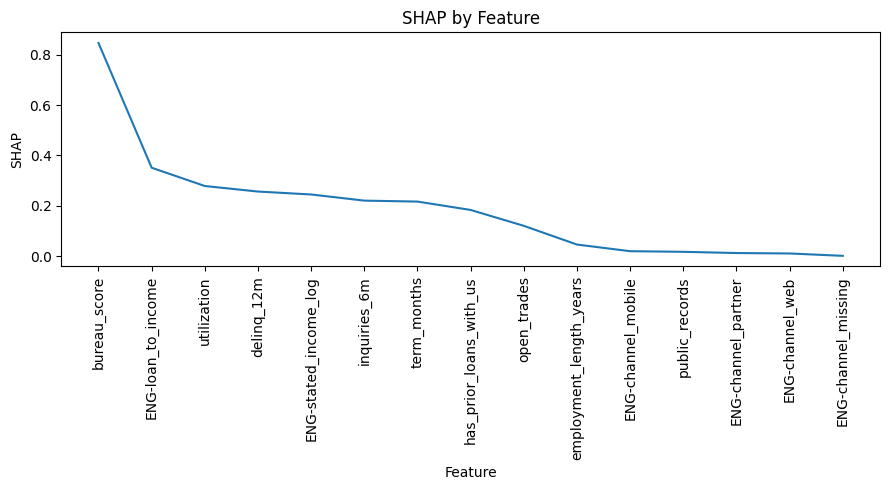

In [30]:
x = df_shap['feature']
y = df_shap['mean_abs_shap']

fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('SHAP by Feature')
ax.set_xlabel('Feature')
ax.set_ylabel('SHAP')
ax.plot(x, y)

plt.xticks(rotation=90)   
plt.tight_layout()        
plt.show()

## Reverse Stepwise Feature Removal (SHAP-Based)

In [31]:
df_shap.sort_values(by='mean_abs_shap', ascending=True, inplace=True)

# get list of cols in the model
list_cols_model = list(cls_model_inference.feature_names_in_)

list_df = []
for feature in df_shap['feature']:
    print(f'Removing {feature}')
    # rm feature from list
    list_cols_model = [col for col in list_cols_model if col != feature]
    # update monotone constraints
    dict_monotone_constraints_tmp = {key: val for key, val in dict_monotone_constraints.items() if key in list_cols_model}
    # tune
    try:
        df_tuning = tune_model(
            X_train=X_train[list_cols_model],
            y_train=y_train,
            X_valid=X_valid[list_cols_model],
            y_valid=y_valid,
            X_test=X_test[list_cols_model],
            y_test=y_test,
            dict_monotone_constraints=dict_monotone_constraints_tmp,
        )
    except IndexError:
        continue
    # make copy
    df_tuning = df_tuning.copy()
    # append
    list_df.append(df_tuning)
    print()
# concat
df_tuning = pd.concat(list_df)
# sort
df_tuning.sort_values(by='flt_pr_auc_valid', ascending=False, inplace=True)
# show
df_tuning

Removing ENG-channel_missing
Fitting model 1 / 18
Fitting model 2 / 18
Fitting model 3 / 18
Fitting model 4 / 18
Fitting model 5 / 18
Fitting model 6 / 18
Fitting model 7 / 18
Fitting model 8 / 18
Fitting model 9 / 18
Fitting model 10 / 18
Fitting model 11 / 18
Fitting model 12 / 18
Fitting model 13 / 18
Fitting model 14 / 18
Fitting model 15 / 18
Fitting model 16 / 18
Fitting model 17 / 18
Fitting model 18 / 18

Removing ENG-channel_web
Fitting model 1 / 18
Fitting model 2 / 18
Fitting model 3 / 18
Fitting model 4 / 18
Fitting model 5 / 18
Fitting model 6 / 18
Fitting model 7 / 18
Fitting model 8 / 18
Fitting model 9 / 18
Fitting model 10 / 18
Fitting model 11 / 18
Fitting model 12 / 18
Fitting model 13 / 18
Fitting model 14 / 18
Fitting model 15 / 18
Fitting model 16 / 18
Fitting model 17 / 18
Fitting model 18 / 18

Removing ENG-channel_partner
Fitting model 1 / 18
Fitting model 2 / 18
Fitting model 3 / 18
Fitting model 4 / 18
Fitting model 5 / 18
Fitting model 6 / 18
Fitting model 7

,flt_pos_weight,int_min_child_weight,flt_gamma,int_max_depth,flt_roc_auc_train,flt_roc_auc_valid,flt_roc_auc_test,flt_pr_auc_train,flt_pr_auc_valid,flt_pr_auc_test,int_best_iteration,cls_model_inference
2,4.263727,1,0.0,5,0.833424,0.799838,0.799528,0.557281,0.493178,0.495998,136,"XGBClassifier(base_score=None, booster=None, c..."
14,4.263727,10,0.0,5,0.835179,0.799106,0.799589,0.560144,0.493078,0.496321,181,"XGBClassifier(base_score=None, booster=None, c..."
11,4.263727,5,0.5,5,0.832990,0.799723,0.799505,0.555817,0.492638,0.495921,134,"XGBClassifier(base_score=None, booster=None, c..."
10,4.263727,5,0.5,4,0.832859,0.798898,0.799435,0.554202,0.492571,0.496472,184,"XGBClassifier(base_score=None, booster=None, c..."
8,4.263727,5,0.0,5,0.833642,0.799118,0.800156,0.557572,0.492486,0.495656,136,"XGBClassifier(base_score=None, booster=None, c..."
...,...,...,...,...,...,...,...,...,...,...,...,...
11,4.263727,5,0.5,5,0.756694,0.747930,0.748039,0.392796,0.375136,0.367357,103,"XGBClassifier(base_score=None, booster=None, c..."
17,4.263727,10,0.5,5,0.756694,0.747930,0.748039,0.392796,0.375136,0.367357,103,"XGBClassifier(base_score=None, booster=None, c..."
9,4.263727,5,0.5,3,0.756753,0.747988,0.748001,0.392588,0.374931,0.367084,103,"XGBClassifier(base_score=None, booster=None, c..."
15,4.263727,10,0.5,3,0.756753,0.747988,0.748001,0.392588,0.374931,0.367084,103,"XGBClassifier(base_score=None, booster=None, c..."


## Select Optimized Model

In [32]:
cls_model_inference = df_tuning['cls_model_inference'].iloc[0]

## Final Feature Count

In [33]:
list_feats_final = list(cls_model_inference.feature_names_in_)
int_n_features = len(list_feats_final)
print(f'N Features: {int_n_features}')

N Features: 11


## Final Model Metrics

In [34]:
for col in ['flt_roc_auc_train','flt_roc_auc_valid','flt_roc_auc_test','flt_pr_auc_train','flt_pr_auc_valid','flt_pr_auc_test']:
    flt_metric = df_tuning[col].iloc[0]
    print(f'{col}: {flt_metric:0.4f}')

flt_roc_auc_train: 0.8334
flt_roc_auc_valid: 0.7998
flt_roc_auc_test: 0.7995
flt_pr_auc_train: 0.5573
flt_pr_auc_valid: 0.4932
flt_pr_auc_test: 0.4960


## Save Tuning Results

In [35]:
str_filename = 'df_tuning.csv'
str_local_path = f'{str_dirname_output}/{str_filename}'
df_tuning.to_csv(
    str_local_path,
    index=False,
)

## SHAP Feature Importance (Final Model)

In [36]:
# sample
X_shap = X_valid[list_feats_final].sample(n=min(5000, len(X_valid[list_feats_final])), random_state=42)
# explainer
explainer = shap.TreeExplainer(cls_model_inference)
shap_values = explainer.shap_values(X_shap)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
# make df
df_shap = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": mean_abs_shap,
})
df_shap.sort_values(by='mean_abs_shap', ascending=False, inplace=True)

# show
df_shap

,feature,mean_abs_shap
3,bureau_score,0.818492
9,ENG-loan_to_income,0.331534
6,utilization,0.251373
5,delinq_12m,0.234475
8,ENG-stated_income_log,0.217056
7,inquiries_6m,0.194308
0,term_months,0.186439
2,has_prior_loans_with_us,0.152033
4,open_trades,0.099602
1,employment_length_years,0.028160


## SHAP Plot (Final Model)

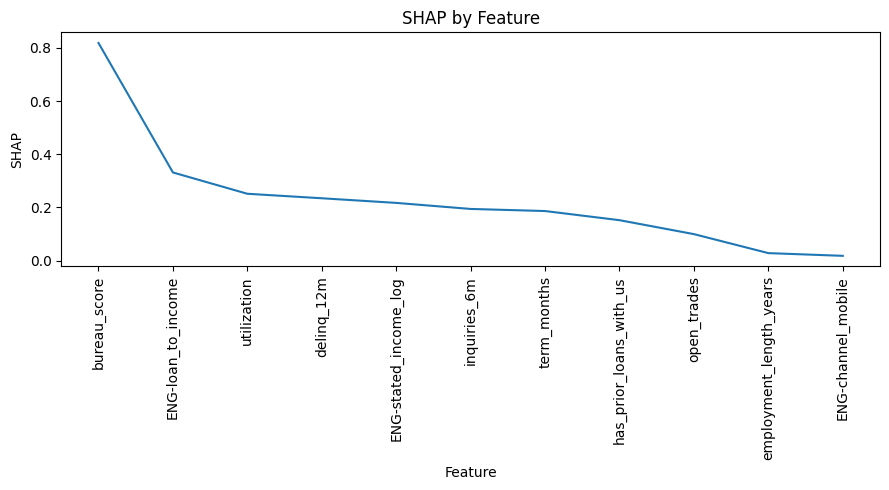

In [37]:
x = df_shap['feature']
y = df_shap['mean_abs_shap']

fig, ax = plt.subplots(figsize=(9,5))
ax.set_title('SHAP by Feature')
ax.set_xlabel('Feature')
ax.set_ylabel('SHAP')
ax.plot(x, y)

plt.xticks(rotation=90)   
plt.tight_layout()        
plt.show()

## Save Inference Model

In [38]:
# save
str_filename = 'cls_model_inference.joblib'
str_local_path = f'{str_dirname_output}/{str_filename}'
joblib.dump(cls_model_inference, str_local_path)

['./output/cls_model_inference.joblib']

## Prediction Distribution Analysis

In [39]:
# import data
df = pd.read_csv(str_uri)
# dtm
df['dob'] = pd.to_datetime(df['dob'], errors='coerce')
# get age
df['age'] = (pd.Timestamp.today() - df['dob']).dt.days // 365
# make binary
df['age_group'] = df['age'].apply(
    lambda x: 'young' if x < 60 else 'old'
)
df

,loan_id,origination_date,dob,loan_amount,term_months,channel,employment_length_years,stated_income,state,has_prior_loans_with_us,...,utilization,inquiries_6m,public_records,default_12m,charged_off_amount,paid_interest_amount,apr,data_set,age,age_group
0,17794,2022-01-01,1992-02-29,5410,18,partner,8.39,2951.0,WI,0,...,0.47,3.0,1,0,0.00,1715.89,0.221,train,34,young
1,13499,2022-01-01,1966-05-05,10000,12,web,4.52,5410.0,FL,0,...,0.46,3.0,0,0,0.00,1672.59,0.209,train,59,young
2,24476,2022-01-01,1985-02-06,8480,12,web,3.81,3244.0,TX,0,...,0.48,5.0,2,0,0.00,2379.19,0.303,train,41,young
3,5438,2022-01-01,1981-11-06,3510,18,web,9.82,5147.0,IL,1,...,0.18,1.0,0,0,0.00,706.84,0.150,train,44,young
4,11493,2022-01-01,1991-11-27,6630,24,web,4.99,6389.0,TX,1,...,0.41,3.0,1,0,0.00,2160.10,0.159,train,34,young
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
25303,23591,2024-12-28,1975-12-12,6970,12,mobile,9.41,6511.0,WA,0,...,0.47,4.0,1,0,0.00,1147.42,0.200,test,50,young
25304,15828,2024-12-28,1984-11-26,8450,12,mobile,8.97,4278.0,TN,1,...,0.52,2.0,0,0,0.00,1163.61,0.160,test,41,young
25305,17304,2024-12-28,2003-07-07,970,24,web,4.01,3885.0,MO,0,...,0.34,0.0,0,0,0.00,287.05,0.166,test,22,young
25306,13374,2024-12-28,1975-12-01,5700,12,mobile,7.10,13121.0,GA,0,...,0.31,2.0,2,0,0.00,803.60,0.156,test,50,young


In [40]:
# import preprocessor
str_filename = 'cls_model_preprocessing.joblib'
str_local_path = f'{str_dirname_output}/{str_filename}'
cls_model_preprocessing = joblib.load(str_local_path)

In [41]:
# preprocess df
df = cls_model_preprocessing.transform(X=df)

Generic cleaning...
Filling missing values...


100%|██████████| 12/12 [00:00<00:00, 1378.08it/s]

Feature engineering...


In [42]:
# import inference model
str_filename = 'cls_model_inference.joblib'
str_local_path = f'{str_dirname_output}/{str_filename}'
cls_model_inference = joblib.load(str_local_path)
# get cols
list_cols_model = list(cls_model_inference.feature_names_in_)

In [43]:
# generate predictions
df['yhat'] = cls_model_inference.predict_proba(df[list_cols_model])[:, 1]

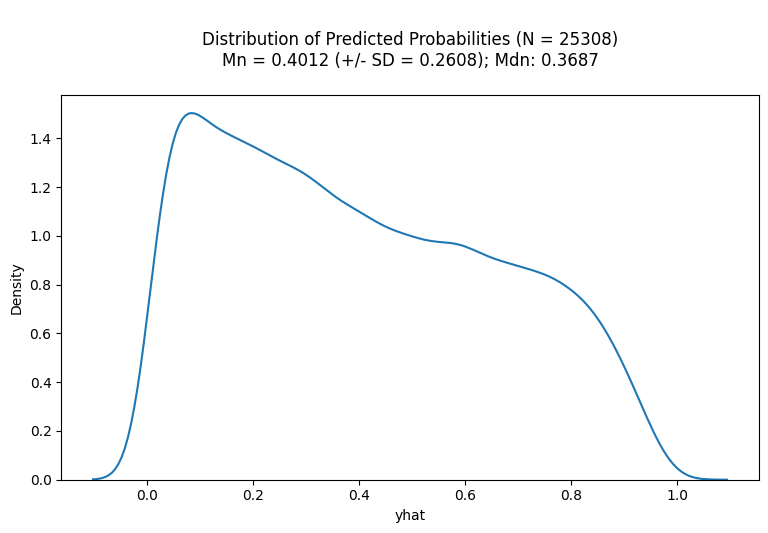

In [44]:
int_n = df.shape[0]
flt_mn = df['yhat'].mean()
flt_sd = df['yhat'].std()
flt_mdn = df['yhat'].median()

# title
str_title = f"""
Distribution of Predicted Probabilities (N = {int_n})
Mn = {flt_mn:0.4f} (+/- SD = {flt_sd:0.4f}); Mdn: {flt_mdn:0.4f}
"""

# ax
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
sns.kdeplot(df['yhat'], ax=ax)
plt.show()

## Disparate Impact Analysis (Age)

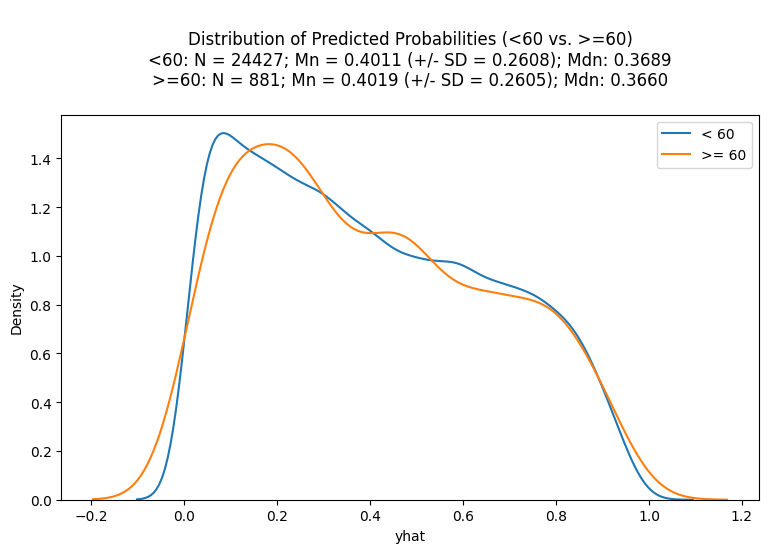

In [45]:
# plot - young
df_young = df[df['age_group'] == 'young'].copy()
int_n_young = df_young.shape[0]
flt_mn_young = df_young['yhat'].mean()
flt_sd_young = df_young['yhat'].std()
flt_mdn_young = df_young['yhat'].median()
# plot - old
df_old = df[df['age_group'] == 'old'].copy()
int_n_old = df_old.shape[0]
flt_mn_old = df_old['yhat'].mean()
flt_sd_old = df_old['yhat'].std()
flt_mdn_old = df_old['yhat'].median()

# title
str_title = f"""
Distribution of Predicted Probabilities (<60 vs. >=60)
<60: N = {int_n_young}; Mn = {flt_mn_young:0.4f} (+/- SD = {flt_sd_young:0.4f}); Mdn: {flt_mdn_young:0.4f}
>=60: N = {int_n_old}; Mn = {flt_mn_old:0.4f} (+/- SD = {flt_sd_old:0.4f}); Mdn: {flt_mdn_old:0.4f}
"""

# ax
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(str_title)
sns.kdeplot(df_young['yhat'], ax=ax, label='< 60')
sns.kdeplot(df_old['yhat'], ax=ax, label='>= 60')
ax.legend()
plt.show()